<!-- CONCLUSION-CELL -->
> ## ✅ 결론 — delta(전년 대비 변화량) feature: **약하지만 유의미 → 채택**
>
> - 30 seed paired t-test (Val R²): nodelta **0.0786** vs delta **0.0802**
> - 평균 차이 **+0.0016**, **t=2.54, p=0.017 (<0.05) ✅**, delta 승 20/30
> - 개선폭은 작지만 통계적으로 유의 → delta feature **유지**.
> - ⚠ 단, 08번 SHAP에서 delta는 하위권(최고 27위)에 머묾 → 기여도는 제한적.


# 07. Delta Feature 기여도 실험 (E1 시리즈)
- X구간: pitch15 고정 (06_x_interval_experiment 결과 기준)
- 비교: delta feature 없는 버전 vs 있는 버전
- 검증: paired t-test (🔬 A/B 테스트)

| 실험 | 내용 |
|---|---|
| E1-1 | 절대값 feature만 (delta 없음) ← 비교 기준 |
| E1-2 | 절대값 + delta feature 전체 |
| 🔬 E1-3 | E1-1 vs E1-2 paired t-test |

In [1]:
# ── 환경 감지 ──────────────────────────────────────────────
import os, sys

IN_COLAB = 'google.colab' in str(get_ipython())

if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    DRIVE = '/content/drive/MyDrive/투수 컨디션 예측 ML'
    NB_DIR = os.path.join(DRIVE, '3_modeling')
    sys.path.insert(0, NB_DIR)
else:
    DRIVE  = os.path.dirname(os.path.abspath('__file__'))
    NB_DIR = os.path.dirname(os.path.abspath('__file__'))

INTERIM_DIR = os.path.join(DRIVE, '0_data', '2_interim')
FEATURE_DIR = os.path.join(DRIVE, '0_data', '4_features')
OUTPUT_DIR  = os.path.join(DRIVE, '4_output')
STARTERS    = os.path.join(INTERIM_DIR, 'starters_all.parquet')
LOOKUP      = os.path.join(INTERIM_DIR, 'prev_season_lookup.parquet')
os.makedirs(OUTPUT_DIR, exist_ok=True)

# X구간 고정: pitch15
MODE = 'pitch'
N    = 15

print(f'환경: {"코랩" if IN_COLAB else "로컬"}')
print(f'X구간: {MODE}{N}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
환경: 코랩
X구간: pitch15


In [2]:
# ── 패키지 ─────────────────────────────────────────────────
try:
    import duckdb, xgboost, catboost, lightgbm
except ImportError:
    import subprocess
    subprocess.run(['pip', 'install', 'duckdb', 'xgboost', 'catboost', 'lightgbm', '-q'])

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import xgboost as xgb
from catboost import CatBoostRegressor
import lightgbm as lgb
from sklearn.metrics import mean_squared_error, r2_score
import importlib
import feature_aggregator
importlib.reload(feature_aggregator)
from feature_aggregator import build_features

print('패키지 로드 완료')

패키지 로드 완료


## 1. 데이터 생성 (delta 있음 / 없음)

In [3]:
# E1-1: delta 없는 버전
df_nodelta = build_features(STARTERS, LOOKUP, MODE, N, include_delta=False)
print(f'E1-1 (no delta): {len(df_nodelta):,}행  |  feature 수: {len(df_nodelta.columns) - 4}')

# E1-2: delta 있는 버전
df_delta = build_features(STARTERS, LOOKUP, MODE, N, include_delta=True)
print(f'E1-2 (with delta): {len(df_delta):,}행  |  feature 수: {len(df_delta.columns) - 4}')

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

E1-1 (no delta): 23,225행  |  feature 수: 29


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

E1-2 (with delta): 23,225행  |  feature 수: 59


## 2. Bootstrap 반복 학습 (paired t-test용)
- 동일 random_state 시드 30개로 반복 학습
- 각 시드별 Val R²를 쌍으로 기록 → paired t-test

In [4]:
META_COLS = ['game_pk', 'pitcher', 'season', 'y_whiff', 'swings']

def get_splits(df):
    meta = [c for c in META_COLS if c in df.columns]
    feat = [c for c in df.columns if c not in meta]
    train = df[df['season'].isin([2021, 2022, 2023])]
    val   = df[df['season'] == 2024]
    return train[feat], train['y_whiff'], val[feat], val['y_whiff']


def train_xgb(X_tr, y_tr, X_val, y_val, seed):
    m = xgb.XGBRegressor(
        n_estimators=500, learning_rate=0.05, max_depth=6,
        subsample=0.8, colsample_bytree=0.8,
        random_state=seed, n_jobs=-1, verbosity=0,
        early_stopping_rounds=50,
    )
    m.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False)
    return r2_score(y_val, m.predict(X_val))


N_SEEDS = 30
SEEDS   = list(range(N_SEEDS))

X_tr_nd, y_tr_nd, X_val_nd, y_val_nd = get_splits(df_nodelta)
X_tr_d,  y_tr_d,  X_val_d,  y_val_d  = get_splits(df_delta)

r2_nodelta = []
r2_delta   = []

for i, seed in enumerate(SEEDS):
    r2_nodelta.append(train_xgb(X_tr_nd, y_tr_nd, X_val_nd, y_val_nd, seed))
    r2_delta.append(train_xgb(X_tr_d,  y_tr_d,  X_val_d,  y_val_d,  seed))
    if (i + 1) % 10 == 0:
        print(f'  {i+1}/{N_SEEDS} 완료')

print('\n반복 학습 완료')
print(f'E1-1 no delta  — 평균 R²: {np.mean(r2_nodelta):.4f} ± {np.std(r2_nodelta):.4f}')
print(f'E1-2 with delta — 평균 R²: {np.mean(r2_delta):.4f} ± {np.std(r2_delta):.4f}')

  10/30 완료
  20/30 완료
  30/30 완료

반복 학습 완료
E1-1 no delta  — 평균 R²: 0.0786 ± 0.0022
E1-2 with delta — 평균 R²: 0.0802 ± 0.0022


## 3. Paired t-test 🔬

In [5]:
t_stat, p_value = stats.ttest_rel(r2_delta, r2_nodelta)
diff = np.array(r2_delta) - np.array(r2_nodelta)

print('=' * 50)
print('Paired t-test: delta feature 기여도')
print('=' * 50)
print(f'E1-1 no delta   평균 R²: {np.mean(r2_nodelta):.4f}')
print(f'E1-2 with delta 평균 R²: {np.mean(r2_delta):.4f}')
print(f'평균 차이 (delta - no delta): {np.mean(diff):+.4f}')
print(f't-statistic: {t_stat:.4f}')
print(f'p-value    : {p_value:.4f}')
print()
if p_value < 0.05:
    print('→ p < 0.05: delta feature가 통계적으로 유의미한 성능 개선 ✅')
else:
    print('→ p ≥ 0.05: 통계적으로 유의미한 차이 없음 ❌')

Paired t-test: delta feature 기여도
E1-1 no delta   평균 R²: 0.0786
E1-2 with delta 평균 R²: 0.0802
평균 차이 (delta - no delta): +0.0016
t-statistic: 2.5386
p-value    : 0.0168

→ p < 0.05: delta feature가 통계적으로 유의미한 성능 개선 ✅


## 4. 결과 시각화

/tmp/ipykernel_40569/494632615.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([r2_nodelta, r2_delta], labels=['E1-1\nno delta', 'E1-2\nwith delta'], patch_artist=True,
/tmp/ipykernel_40569/494632615.py:22: UserWarning: Glyph 48516 (\N{HANGUL SYLLABLE BUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_40569/494632615.py:22: UserWarning: Glyph 54252 (\N{HANGUL SYLLABLE PO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_40569/494632615.py:22: UserWarning: Glyph 48708 (\N{HANGUL SYLLABLE BI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_40569/494632615.py:22: UserWarning: Glyph 44368 (\N{HANGUL SYLLABLE GYO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_40569/494632615.py:22: UserWarning: Glyph 52264 (\N{HANGUL SYLLABLE CA}) missing from font(s) DejaVu S

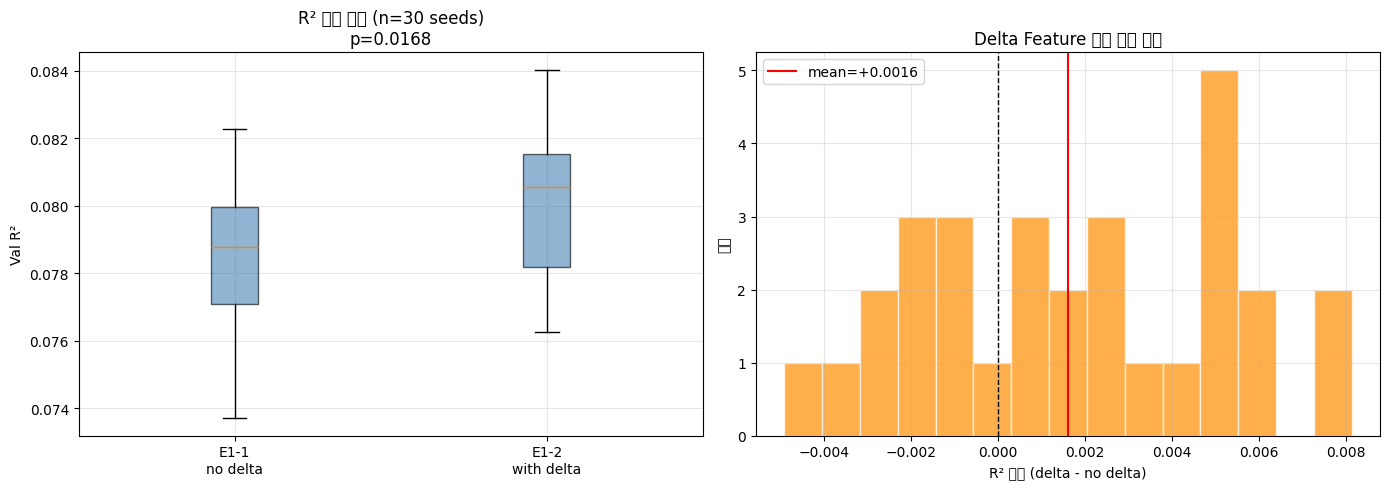

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 박스플롯
ax = axes[0]
ax.boxplot([r2_nodelta, r2_delta], labels=['E1-1\nno delta', 'E1-2\nwith delta'], patch_artist=True,
           boxprops=dict(facecolor='steelblue', alpha=0.6))
ax.set_ylabel('Val R²')
ax.set_title(f'R² 분포 비교 (n={N_SEEDS} seeds)\np={p_value:.4f}')
ax.grid(alpha=0.3)

# 차이 분포
ax = axes[1]
ax.hist(diff, bins=15, color='darkorange', alpha=0.7, edgecolor='white')
ax.axvline(0, color='black', linestyle='--', linewidth=1)
ax.axvline(np.mean(diff), color='red', linestyle='-', linewidth=1.5, label=f'mean={np.mean(diff):+.4f}')
ax.set_xlabel('R² 차이 (delta - no delta)')
ax.set_ylabel('빈도')
ax.set_title('Delta Feature 기여 차이 분포')
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 5. 결과 저장

In [7]:
result_df = pd.DataFrame({
    'seed':       SEEDS,
    'r2_nodelta': r2_nodelta,
    'r2_delta':   r2_delta,
    'diff':       diff,
})

summary = {
    'E1-1 no delta mean R²':   round(np.mean(r2_nodelta), 4),
    'E1-2 with delta mean R²': round(np.mean(r2_delta), 4),
    'mean diff':               round(np.mean(diff), 4),
    't_stat':                  round(t_stat, 4),
    'p_value':                 round(p_value, 4),
    'significant':             p_value < 0.05,
}

out = os.path.join(OUTPUT_DIR, 'delta_experiment_results.csv')
result_df.to_csv(out, index=False)
print(f'저장 완료 → {out}')
print()
for k, v in summary.items():
    print(f'  {k}: {v}')

저장 완료 → /content/drive/MyDrive/투수 컨디션 예측 ML/4_output/delta_experiment_results.csv

  E1-1 no delta mean R²: 0.0786
  E1-2 with delta mean R²: 0.0802
  mean diff: 0.0016
  t_stat: 2.5386
  p_value: 0.0168
  significant: True
